In [1]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import ROOT

In [2]:
base_dir = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/NTuples_bbgg_2024_notrigger/WH-2024M60/"

In [3]:
nominal = base_dir + 'nominal/diphoton/'

In [4]:
material_up = base_dir + 'Material_up/diphoton'

In [5]:
material_down = base_dir + 'Material_down/diphoton'

In [16]:
Fnuf_up = base_dir + 'FNUF_up/diphoton'
ScaleEE2G_IJazZ_down = base_dir + 'ScaleEE2G_IJazZ_down/diphoton'
ScaleEE2G_IJazZ_up = base_dir + 'ScaleEE2G_IJazZ_up/diphoton'

In [10]:
Fnuf_down = base_dir + 'FNUF_down/diphoton'

In [6]:
file = ak.from_parquet(nominal)

In [7]:
file_matup = ak.from_parquet(material_up)

In [8]:
file_matdown = ak.from_parquet(material_down)

In [9]:
file_fnufup = ak.from_parquet(Fnuf_up)

In [17]:
file_fndown = ak.from_parquet(Fnuf_down)
file_scaleEE2G_IJazZ_up = ak.from_parquet(ScaleEE2G_IJazZ_up)
file_scaleEE2G_IJazZ_down = ak.from_parquet(ScaleEE2G_IJazZ_down)

In [7]:
file_matup.fields

['pholead_cutBased',
 'pholead_electronVeto',
 'pholead_hasConversionTracks',
 'pholead_isScEtaEB',
 'pholead_isScEtaEE',
 'pholead_mvaID_WP80',
 'pholead_mvaID_WP90',
 'pholead_pixelSeed',
 'pholead_seedGain',
 'pholead_electronIdx',
 'pholead_jetIdx',
 'pholead_seediEtaOriX',
 'pholead_seediPhiOriY',
 'pholead_vidNestedWPBitmap',
 'pholead_ecalPFClusterIso',
 'pholead_energyErr',
 'pholead_energyRaw',
 'pholead_esEffSigmaRR',
 'pholead_esEnergyOverRawE',
 'pholead_eta',
 'pholead_etaWidth',
 'pholead_haloTaggerMVAVal',
 'pholead_hcalPFClusterIso',
 'pholead_hoe',
 'pholead_hoe_PUcorr',
 'pholead_hoe_Tower',
 'pholead_mvaID',
 'pholead_pfChargedIso',
 'pholead_pfChargedIsoPFPV',
 'pholead_pfChargedIsoWorstVtx',
 'pholead_pfPhoIso03',
 'pholead_pfRelIso03_all_quadratic',
 'pholead_pfRelIso03_chg_quadratic',
 'pholead_phi',
 'pholead_phiWidth',
 'pholead_r9',
 'pholead_s4',
 'pholead_sieie',
 'pholead_sieip',
 'pholead_sipip',
 'pholead_superclusterEta',
 'pholead_trkSumPtHollowConeDR03

In [8]:
file.fields

['pholead_cutBased',
 'pholead_electronVeto',
 'pholead_hasConversionTracks',
 'pholead_isScEtaEB',
 'pholead_isScEtaEE',
 'pholead_mvaID_WP80',
 'pholead_mvaID_WP90',
 'pholead_pixelSeed',
 'pholead_seedGain',
 'pholead_electronIdx',
 'pholead_jetIdx',
 'pholead_seediEtaOriX',
 'pholead_seediPhiOriY',
 'pholead_vidNestedWPBitmap',
 'pholead_ecalPFClusterIso',
 'pholead_energyErr',
 'pholead_energyRaw',
 'pholead_esEffSigmaRR',
 'pholead_esEnergyOverRawE',
 'pholead_eta',
 'pholead_etaWidth',
 'pholead_haloTaggerMVAVal',
 'pholead_hcalPFClusterIso',
 'pholead_hoe',
 'pholead_hoe_PUcorr',
 'pholead_hoe_Tower',
 'pholead_mvaID',
 'pholead_pfChargedIso',
 'pholead_pfChargedIsoPFPV',
 'pholead_pfChargedIsoWorstVtx',
 'pholead_pfPhoIso03',
 'pholead_pfRelIso03_all_quadratic',
 'pholead_pfRelIso03_chg_quadratic',
 'pholead_phi',
 'pholead_phiWidth',
 'pholead_r9',
 'pholead_s4',
 'pholead_sieie',
 'pholead_sieip',
 'pholead_sipip',
 'pholead_superclusterEta',
 'pholead_trkSumPtHollowConeDR03

In [36]:
file.pholead_pt

<Array [36.8, 33.6, 24.3, ... 26.3, 47.1, 24.1] type='1644 * ?float64'>

In [37]:
file.pholead_ScEta

<Array [-2.11, 1.34, 2.45, ... -1.76, 2.32] type='1644 * ?float32'>

In [38]:
file.pholead_r9

<Array [1.01, 0.994, 1.08, ... 1.01, 1.09] type='1644 * ?float32'>

In [6]:
Plot_dir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/"

In [46]:
ROOT.gStyle.SetOptStat(0)

import csv

# =========================
# Read CSV
# =========================

filename = "Miscellaneous/material_all_systematics.csv"

data = []

with open(filename) as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append({
            "systematic": row["systematic"],
            "eta_min": float(row["SCEta_min"]),
            "eta_max": float(row["SCEta_max"]),
            "r9_min": float(row["r9_min"]),
            "r9_max": float(row["r9_max"]),
            "Ecorr": float(row["Ecorr"])
        })

# =========================
# Extract helper
# =========================

def extract(systematic, low_r9=True):
    subset = [
        d for d in data
        if d["systematic"] == systematic
        and ((low_r9 and d["r9_max"] == 0.94) or
             (not low_r9 and d["r9_min"] == 0.94))
    ]

    subset = sorted(subset, key=lambda x: x["eta_min"])

    x, y = [], []
    for d in subset:
        eta_max = min(d["eta_max"], 2.5)
        eta_center = 0.5 * (d["eta_min"] + eta_max)
        x.append(eta_center)
        y.append(d["Ecorr"])

    return x, y


# =========================
# Build graph
# =========================

def make_graph(x, y, color, marker, linestyle=1):
    g = ROOT.TGraph(len(x))
    for i in range(len(x)):
        g.SetPoint(i, x[i], y[i])
    g.SetLineColor(color)
    g.SetMarkerColor(color)
    g.SetMarkerStyle(marker)
    g.SetLineWidth(2)
    g.SetLineStyle(linestyle)
    return g


# Extract all
x_up_low, y_up_low = extract("up", True)
x_up_high, y_up_high = extract("up", False)
x_down_low, y_down_low = extract("down", True)
x_down_high, y_down_high = extract("down", False)
x_def_low, y_def_low = extract("default", True)
x_def_high, y_def_high = extract("default", False)

g_up_low = make_graph(x_up_low, y_up_low, ROOT.kRed, 20)
g_up_high = make_graph(x_up_high, y_up_high, ROOT.kRed+2, 24)
g_down_low = make_graph(x_down_low, y_down_low, ROOT.kBlue, 21)
g_down_high = make_graph(x_down_high, y_down_high, ROOT.kBlue+2, 25)
g_def_low = make_graph(x_def_low, y_def_low, ROOT.kBlack, 23, 2)
g_def_high = make_graph(x_def_high, y_def_high, ROOT.kBlack, 26, 2)

# =========================
# Draw
# =========================

c = ROOT.TCanvas("c", "", 800, 600)
c.SetLeftMargin(0.15)

frame = ROOT.TH1F("frame", "", 100, 0, 2.6)
frame.SetMinimum(0.996)
frame.SetMaximum(1.004)
frame.GetXaxis().SetTitle("|#eta| bin center")
frame.GetYaxis().SetTitle("p_{T} correction factor")
frame.Draw()

# Reference line at 1
line = ROOT.TLine(0, 1.0, 2.6, 1.0)
line.SetLineStyle(2)
line.Draw()

# Draw graphs
g_def_low.Draw("PL SAME")
g_def_high.Draw("PL SAME")
g_up_low.Draw("PL SAME")
g_up_high.Draw("PL SAME")
g_down_low.Draw("PL SAME")
g_down_high.Draw("PL SAME")

leg = ROOT.TLegend(0.18, 0.62, 0.45, 0.88)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.028)

leg.AddEntry(g_def_low, "Default, R9 < 0.94", "lp")
leg.AddEntry(g_def_high, "Default, R9 #geq 0.94", "lp")
leg.AddEntry(g_up_low, "Up, R9 < 0.94", "lp")
leg.AddEntry(g_up_high, "Up, R9 #geq 0.94", "lp")
leg.AddEntry(g_down_low, "Down, R9 < 0.94", "lp")
leg.AddEntry(g_down_high, "Down, R9 #geq 0.94", "lp")

leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.78, 0.85, "Material")

c.Update()
c.SaveAs(Plot_dir+"material_systematics_plot.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/material_systematics_plot.png has been created


In [47]:
ROOT.gStyle.SetOptStat(0)

# =========================
# Read CSV
# =========================

filename = "Miscellaneous/fnuf_all_systematics.csv"

data = []

with open(filename) as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append({
            "systematic": row["systematic"],
            "eta_min": float(row["eta_min"]),
            "eta_max": float(row["eta_max"]),
            "r9_min": float(row["r9_min"]),
            "r9_max": float(row["r9_max"]),
            "Ecorr": float(row["value"])
        })

# =========================
# Extract helper
# =========================

def extract(systematic, low_r9=True):
    subset = [
        d for d in data
        if d["systematic"] == systematic
        and ((low_r9 and d["r9_max"] == 0.975) or
             (not low_r9 and d["r9_min"] == 0.975))
    ]

    subset = sorted(subset, key=lambda x: x["eta_min"])

    x, y = [], []
    for d in subset:
        eta_max = min(d["eta_max"], 7.0)
        eta_center = 0.5 * (d["eta_min"] + eta_max)
        x.append(eta_center)
        y.append(d["Ecorr"])

    return x, y


# =========================
# Build graph
# =========================

def make_graph(x, y, color, marker, linestyle=1):
    g = ROOT.TGraph(len(x))
    for i in range(len(x)):
        g.SetPoint(i, x[i], y[i])
    g.SetLineColor(color)
    g.SetMarkerColor(color)
    g.SetMarkerStyle(marker)
    g.SetLineWidth(2)
    g.SetLineStyle(linestyle)
    return g


# Extract all
x_up_low, y_up_low = extract("up", True)
x_up_high, y_up_high = extract("up", False)
x_down_low, y_down_low = extract("down", True)
x_down_high, y_down_high = extract("down", False)
x_def_low, y_def_low = extract("nominal", True)
x_def_high, y_def_high = extract("nominal", False)

g_up_low = make_graph(x_up_low, y_up_low, ROOT.kRed, 20)
g_up_high = make_graph(x_up_high, y_up_high, ROOT.kRed+2, 24)
g_down_low = make_graph(x_down_low, y_down_low, ROOT.kBlue, 21)
g_down_high = make_graph(x_down_high, y_down_high, ROOT.kBlue+2, 25)
g_def_low = make_graph(x_def_low, y_def_low, ROOT.kBlack, 23, 2)
g_def_high = make_graph(x_def_high, y_def_high, ROOT.kBlack, 26, 2)

# =========================
# Draw
# =========================

c = ROOT.TCanvas("c", "", 800, 600)
c.SetLeftMargin(0.15)

frame = ROOT.TH1F("frame", "", 100, 0, 4.5)
frame.SetMinimum(0.992)
frame.SetMaximum(1.008)
frame.GetXaxis().SetTitle("|#eta| bin center")
frame.GetYaxis().SetTitle("p_{T} correction factor")
frame.Draw()

# Reference line at 1
line = ROOT.TLine(0, 1.0, 4.5, 1.0)
line.SetLineStyle(2)
line.Draw()

# Draw graphs
g_def_low.Draw("PL SAME")
g_def_high.Draw("PL SAME")
g_up_low.Draw("PL SAME")
g_up_high.Draw("PL SAME")
g_down_low.Draw("PL SAME")
g_down_high.Draw("PL SAME")

leg = ROOT.TLegend(0.18, 0.62, 0.45, 0.90)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.022)

leg.AddEntry(g_def_low, "Nominal, R9 < 0.975", "lp")
leg.AddEntry(g_def_high, "Nominal, R9 #geq 0.975", "lp")
leg.AddEntry(g_up_low, "Up, R9 < 0.975", "lp")
leg.AddEntry(g_up_high, "Up, R9 #geq 0.975", "lp")
leg.AddEntry(g_down_low, "Down, R9 < 0.975", "lp")
leg.AddEntry(g_down_high, "Down, R9 #geq 0.975", "lp")

leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.78, 0.85, "FNUF")

c.Update()
c.SaveAs(Plot_dir+"FNUF_systematics_plot.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/FNUF_systematics_plot.png has been created


In [48]:
import csv

ROOT.gStyle.SetOptStat(0)

filename = "Miscellaneous/EGMSmearAndSyst_PhoPTsplit_20242G.csv"

data = []

# =========================
# Read CSV
# =========================
with open(filename, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["syst"] in ["smear", "smear_up", "smear_down"]:
            data.append({
                "type": row["syst"],
                "pt_min": float(row["pt_min"]),
                "pt_max": float(row["pt_max"]),
                "r9_min": round(float(row["r9_min"]), 3),
                "r9_max": round(float(row["r9_max"]), 3),
                "eta_min": round(float(row["AbsScEta_min"]), 3),
                "eta_max": round(float(row["AbsScEta_max"]), 3),
                "value": float(row["value"])
            })

# =========================
# Unique bins
# =========================
types = sorted(set(d["type"] for d in data))
eta_bins = sorted(set((d["eta_min"], d["eta_max"]) for d in data))
r9_bins = sorted(set((d["r9_min"], d["r9_max"]) for d in data))

# =========================
# Styling
# =========================
color_map = {
    "smear": ROOT.kBlack,
    "smear_up": ROOT.kRed,
    "smear_down": ROOT.kBlue
}

line_styles = {}
for i, r9 in enumerate(r9_bins):
    line_styles[r9] = 1 if i == 0 else 2  # solid / dashed

r9_labels = {}
for r9 in r9_bins:
    r9_min, r9_max = r9
    r9_labels[r9] = f"{r9_min:.2f} < R9 < {r9_max:.2f}"


# =========================
# Canvas
# =========================
c = ROOT.TCanvas("c", "", 1200, 900)
c.Divide(2, 2)


all_graphs = []  # IMPORTANT: store graphs to avoid GC

# =========================
# Loop over eta bins
# =========================

global_max = max(d["value"] for d in data)
global_min = min(d["value"] for d in data)

wanted_types = ["smear", "smear_up", "smear_down"]

# =========================
# Create legend ONCE
# =========================
leg = ROOT.TLegend(0.50, 0.50, 0.75, 0.85)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)


for i_eta, (eta_min, eta_max) in enumerate(eta_bins):

    pad = c.cd(i_eta + 1)
    pad.SetLeftMargin(0.08)
    pad.SetBottomMargin(0.08)
    pad.SetRightMargin(0.05)
    pad.SetTopMargin(0.05)
    pad.SetTicks(1, 1)

    pad.Modified()
    pad.Update()


    # Filter values for this eta bin
    valid_values = [
        d["value"] for d in data
        if d["eta_min"] == eta_min
        and d["eta_max"] == eta_max
    ]

    if not valid_values:
        continue

    ymax = max(valid_values) * 1.3

    # =========================
    # Create MultiGraph (correct axis handling)
    # =========================
    mg = ROOT.TMultiGraph()

    for t in wanted_types:

        if t not in types:
            continue

        for r9 in r9_bins:

            subset = [
                d for d in data
                if d["type"] == t
                and d["eta_min"] == eta_min
                and d["eta_max"] == eta_max
                and d["r9_min"] == r9[0]
                and d["r9_max"] == r9[1]
            ]

            if not subset:
                continue

            subset = sorted(subset, key=lambda x: x["pt_min"])

            g = ROOT.TGraph(len(subset))

            for i, d in enumerate(subset):
                pt_center = 0.5 * (d["pt_min"] + min(d["pt_max"], 200))
                g.SetPoint(i, pt_center, d["value"])

            g.SetLineColor(color_map[t])
            g.SetMarkerColor(color_map[t])
            g.SetLineStyle(line_styles[r9])
            g.SetLineWidth(1)
            g.SetMarkerStyle(20)
            g.SetMarkerSize(0.5)

            mg.Add(g)
            all_graphs.append(g)

            if i_eta == 0:
                label_type = {
                    "smear": "Nominal",
                    "smear_up": "Up",
                    "smear_down": "Down"
                }[t]

                label_r9 = r9_labels[r9]

                leg.AddEntry(g, f"{label_type} ({label_r9})", "lp")


    # ---- Draw multigraph ONCE ----
    mg.Draw("APL")

    mg.GetXaxis().SetTitle("Photon p_{T} bin center [GeV]")
    mg.GetYaxis().SetTitle("Smear")

    mg.SetMinimum(global_min * 1.1)
    mg.SetMaximum(global_max * 1.1)

    mg.GetXaxis().SetTitleSize(0.03)
    mg.GetYaxis().SetTitleSize(0.04)
    mg.GetXaxis().SetLabelSize(0.035)
    mg.GetYaxis().SetLabelSize(0.035)
    mg.GetXaxis().SetTitleOffset(1.2)
    mg.GetYaxis().SetTitleOffset(1.1)

    all_graphs.append(mg)

    # Eta label
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.05)
    latex.DrawLatex(0.20, 0.85,
        f"{eta_min} < |#eta| < {eta_max}")


    pad.RedrawAxis()
    pad.Modified()
    pad.Update()

# Draw legend once
c.cd(1)
leg.Draw()

c.Update()
c.SaveAs(Plot_dir+"smearing_multipad.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/smearing_multipad.png has been created


In [49]:
import csv

ROOT.gStyle.SetOptStat(0)

filename = "Miscellaneous/EGMSmearAndSyst_PhoPTsplit_20242G.csv"

data = []

wanted_types = ["mu"]

# =========================
# Read CSV
# =========================
with open(filename, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["syst"] in wanted_types:
            data.append({
                "type": row["syst"],
                "pt_min": float(row["pt_min"]),
                "pt_max": float(row["pt_max"]),
                "r9_min": round(float(row["r9_min"]), 3),
                "r9_max": round(float(row["r9_max"]), 3),
                "eta_min": round(float(row["AbsScEta_min"]), 3),
                "eta_max": round(float(row["AbsScEta_max"]), 3),
                "value": float(row["value"])
            })

# =========================
# Unique bins
# =========================
types = sorted(set(d["type"] for d in data))
eta_bins = sorted(set((d["eta_min"], d["eta_max"]) for d in data))
r9_bins = sorted(set((d["r9_min"], d["r9_max"]) for d in data))

# =========================
# Styling
# =========================
color_map = {
    "mu": ROOT.kBlack
}

line_styles = {}
for i, r9 in enumerate(r9_bins):
    line_styles[r9] = 1 if i == 0 else 2  # solid / dashed

r9_labels = {}
for r9 in r9_bins:
    r9_min, r9_max = r9
    r9_labels[r9] = f"{r9_min:.2f} < R9 < {r9_max:.2f}"


# =========================
# Canvas
# =========================
c = ROOT.TCanvas("c", "", 1200, 900)
c.Divide(2, 2)


all_graphs = []  # IMPORTANT: store graphs to avoid GC

# =========================
# Loop over eta bins
# =========================

global_max = max(d["value"] for d in data)
global_min = min(d["value"] for d in data)

# =========================
# Create legend ONCE
# =========================
leg = ROOT.TLegend(0.50, 0.50, 0.75, 0.65)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)


for i_eta, (eta_min, eta_max) in enumerate(eta_bins):

    pad = c.cd(i_eta + 1)
    pad.SetLeftMargin(0.08)
    pad.SetBottomMargin(0.08)
    pad.SetRightMargin(0.05)
    pad.SetTopMargin(0.05)
    pad.SetTicks(1, 1)

    pad.Modified()
    pad.Update()


    # Filter values for this eta bin
    valid_values = [
        d["value"] for d in data
        if d["eta_min"] == eta_min
        and d["eta_max"] == eta_max
    ]

    if not valid_values:
        continue

    ymax = max(valid_values) * 1.3

    # =========================
    # Create MultiGraph (correct axis handling)
    # =========================
    mg = ROOT.TMultiGraph()

    for t in wanted_types:

        if t not in types:
            continue

        for r9 in r9_bins:

            subset = [
                d for d in data
                if d["type"] == t
                and d["eta_min"] == eta_min
                and d["eta_max"] == eta_max
                and d["r9_min"] == r9[0]
                and d["r9_max"] == r9[1]
            ]

            if not subset:
                continue

            subset = sorted(subset, key=lambda x: x["pt_min"])

            g = ROOT.TGraph(len(subset))

            for i, d in enumerate(subset):
                pt_center = 0.5 * (d["pt_min"] + min(d["pt_max"], 200))
                g.SetPoint(i, pt_center, d["value"])

            g.SetLineColor(color_map[t])
            g.SetMarkerColor(color_map[t])
            g.SetLineStyle(line_styles[r9])
            g.SetLineWidth(1)
            g.SetMarkerStyle(20)
            g.SetMarkerSize(0.5)

            mg.Add(g)
            all_graphs.append(g)

            if i_eta == 0:
                label_type = {
                    "mu": "Nominal"
                }[t]

                label_r9 = r9_labels[r9]

                leg.AddEntry(g, f"{label_type} ({label_r9})", "lp")


    # ---- Draw multigraph ONCE ----
    mg.Draw("APL")

    mg.GetXaxis().SetTitle("Photon p_{T} bin center [GeV]")
    mg.GetYaxis().SetTitle("Mu")

    mg.SetMinimum(global_min * 1.1)
    mg.SetMaximum(global_max * 1.1)

    mg.GetXaxis().SetTitleSize(0.03)
    mg.GetYaxis().SetTitleSize(0.04)
    mg.GetXaxis().SetLabelSize(0.035)
    mg.GetYaxis().SetLabelSize(0.035)
    mg.GetXaxis().SetTitleOffset(1.2)
    mg.GetYaxis().SetTitleOffset(1.1)

    all_graphs.append(mg)

    # Eta label
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.05)
    latex.DrawLatex(0.20, 0.85,
        f"{eta_min} < |#eta| < {eta_max}")


    pad.RedrawAxis()
    pad.Modified()
    pad.Update()

# Draw legend once
c.cd(1)
leg.Draw()

c.Update()
c.SaveAs(Plot_dir+"mu_multipad.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/mu_multipad.png has been created


In [50]:
import csv

ROOT.gStyle.SetOptStat(0)

filename = "Miscellaneous/EGMSmearAndSyst_PhoPTsplit_20242G.csv"

data = []

wanted_types = ["frac"]

# =========================
# Read CSV
# =========================
with open(filename, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["syst"] in wanted_types:
            data.append({
                "type": row["syst"],
                "pt_min": float(row["pt_min"]),
                "pt_max": float(row["pt_max"]),
                "r9_min": round(float(row["r9_min"]), 3),
                "r9_max": round(float(row["r9_max"]), 3),
                "eta_min": round(float(row["AbsScEta_min"]), 3),
                "eta_max": round(float(row["AbsScEta_max"]), 3),
                "value": float(row["value"])
            })

# =========================
# Unique bins
# =========================
types = sorted(set(d["type"] for d in data))
eta_bins = sorted(set((d["eta_min"], d["eta_max"]) for d in data))
r9_bins = sorted(set((d["r9_min"], d["r9_max"]) for d in data))

# =========================
# Styling
# =========================
color_map = {
    "frac": ROOT.kBlack
}

line_styles = {}
for i, r9 in enumerate(r9_bins):
    line_styles[r9] = 1 if i == 0 else 2  # solid / dashed

r9_labels = {}
for r9 in r9_bins:
    r9_min, r9_max = r9
    r9_labels[r9] = f"{r9_min:.2f} < R9 < {r9_max:.2f}"


# =========================
# Canvas
# =========================
c = ROOT.TCanvas("c", "", 1200, 900)
c.Divide(2, 2)


all_graphs = []  # IMPORTANT: store graphs to avoid GC

# =========================
# Loop over eta bins
# =========================

global_max = max(d["value"] for d in data)
global_min = min(d["value"] for d in data)

# =========================
# Create legend ONCE
# =========================
leg = ROOT.TLegend(0.50, 0.50, 0.75, 0.65)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)


for i_eta, (eta_min, eta_max) in enumerate(eta_bins):

    pad = c.cd(i_eta + 1)
    pad.SetLeftMargin(0.08)
    pad.SetBottomMargin(0.08)
    pad.SetRightMargin(0.05)
    pad.SetTopMargin(0.05)
    pad.SetTicks(1, 1)

    pad.Modified()
    pad.Update()


    # Filter values for this eta bin
    valid_values = [
        d["value"] for d in data
        if d["eta_min"] == eta_min
        and d["eta_max"] == eta_max
    ]

    if not valid_values:
        continue

    ymax = max(valid_values) * 1.3

    # =========================
    # Create MultiGraph (correct axis handling)
    # =========================
    mg = ROOT.TMultiGraph()

    for t in wanted_types:

        if t not in types:
            continue

        for r9 in r9_bins:

            subset = [
                d for d in data
                if d["type"] == t
                and d["eta_min"] == eta_min
                and d["eta_max"] == eta_max
                and d["r9_min"] == r9[0]
                and d["r9_max"] == r9[1]
            ]

            if not subset:
                continue

            subset = sorted(subset, key=lambda x: x["pt_min"])

            g = ROOT.TGraph(len(subset))

            for i, d in enumerate(subset):
                pt_center = 0.5 * (d["pt_min"] + min(d["pt_max"], 200))
                g.SetPoint(i, pt_center, d["value"])

            g.SetLineColor(color_map[t])
            g.SetMarkerColor(color_map[t])
            g.SetLineStyle(line_styles[r9])
            g.SetLineWidth(1)
            g.SetMarkerStyle(20)
            g.SetMarkerSize(0.5)

            mg.Add(g)
            all_graphs.append(g)

            if i_eta == 0:
                label_type = {
                    "frac": "Nominal"
                }[t]

                label_r9 = r9_labels[r9]

                leg.AddEntry(g, f"{label_type} ({label_r9})", "lp")


    # ---- Draw multigraph ONCE ----
    mg.Draw("APL")

    mg.GetXaxis().SetTitle("Photon p_{T} bin center [GeV]")
    mg.GetYaxis().SetTitle("Frac")

    # mg.SetMinimum(global_min * 1.1)
    # mg.SetMaximum(global_max * 1.1)

    margin = 0.1 * (global_max - global_min)

    mg.SetMinimum(global_min - margin)
    mg.SetMaximum(global_max + margin)


    mg.GetXaxis().SetTitleSize(0.03)
    mg.GetYaxis().SetTitleSize(0.04)
    mg.GetXaxis().SetLabelSize(0.035)
    mg.GetYaxis().SetLabelSize(0.035)
    mg.GetXaxis().SetTitleOffset(1.2)
    mg.GetYaxis().SetTitleOffset(1.1)

    all_graphs.append(mg)

    # Eta label
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.05)
    latex.DrawLatex(0.68, 0.15,
        f"{eta_min} < |#eta| < {eta_max}")


    pad.RedrawAxis()
    pad.Modified()
    pad.Update()

# Draw legend once
c.cd(1)
leg.Draw()

c.Update()
c.SaveAs(Plot_dir+"frac_multipad.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/frac_multipad.png has been created


In [51]:
import csv

ROOT.gStyle.SetOptStat(0)

filename = "Miscellaneous/EGMSmearAndSyst_PhoPTsplit_20242G.csv"

data = []

wanted_types = ["reso_scale"]

# =========================
# Read CSV
# =========================
with open(filename, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["syst"] in wanted_types:
            data.append({
                "type": row["syst"],
                "pt_min": float(row["pt_min"]),
                "pt_max": float(row["pt_max"]),
                "r9_min": round(float(row["r9_min"]), 3),
                "r9_max": round(float(row["r9_max"]), 3),
                "eta_min": round(float(row["AbsScEta_min"]), 3),
                "eta_max": round(float(row["AbsScEta_max"]), 3),
                "value": float(row["value"])
            })

# =========================
# Unique bins
# =========================
types = sorted(set(d["type"] for d in data))
eta_bins = sorted(set((d["eta_min"], d["eta_max"]) for d in data))
r9_bins = sorted(set((d["r9_min"], d["r9_max"]) for d in data))

# =========================
# Styling
# =========================
color_map = {
    "reso_scale": ROOT.kBlack
}

line_styles = {}
for i, r9 in enumerate(r9_bins):
    line_styles[r9] = 1 if i == 0 else 2  # solid / dashed

r9_labels = {}
for r9 in r9_bins:
    r9_min, r9_max = r9
    r9_labels[r9] = f"{r9_min:.2f} < R9 < {r9_max:.2f}"


# =========================
# Canvas
# =========================
c = ROOT.TCanvas("c", "", 1200, 900)
c.Divide(2, 2)


all_graphs = []  # IMPORTANT: store graphs to avoid GC

# =========================
# Loop over eta bins
# =========================

global_max = max(d["value"] for d in data)
global_min = min(d["value"] for d in data)

# =========================
# Create legend ONCE
# =========================
leg = ROOT.TLegend(0.15, 0.70, 0.25, 0.85)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)


for i_eta, (eta_min, eta_max) in enumerate(eta_bins):

    pad = c.cd(i_eta + 1)
    pad.SetLeftMargin(0.08)
    pad.SetBottomMargin(0.08)
    pad.SetRightMargin(0.05)
    pad.SetTopMargin(0.05)
    pad.SetTicks(1, 1)

    pad.Modified()
    pad.Update()


    # Filter values for this eta bin
    valid_values = [
        d["value"] for d in data
        if d["eta_min"] == eta_min
        and d["eta_max"] == eta_max
    ]

    if not valid_values:
        continue

    ymax = max(valid_values) * 1.3

    # =========================
    # Create MultiGraph (correct axis handling)
    # =========================
    mg = ROOT.TMultiGraph()

    for t in wanted_types:

        if t not in types:
            continue

        for r9 in r9_bins:

            subset = [
                d for d in data
                if d["type"] == t
                and d["eta_min"] == eta_min
                and d["eta_max"] == eta_max
                and d["r9_min"] == r9[0]
                and d["r9_max"] == r9[1]
            ]

            if not subset:
                continue

            subset = sorted(subset, key=lambda x: x["pt_min"])

            g = ROOT.TGraph(len(subset))

            for i, d in enumerate(subset):
                pt_center = 0.5 * (d["pt_min"] + min(d["pt_max"], 200))
                g.SetPoint(i, pt_center, d["value"])

            g.SetLineColor(color_map[t])
            g.SetMarkerColor(color_map[t])
            g.SetLineStyle(line_styles[r9])
            g.SetLineWidth(1)
            g.SetMarkerStyle(20)
            g.SetMarkerSize(0.5)

            mg.Add(g)
            all_graphs.append(g)

            if i_eta == 0:
                label_type = {
                    "reso_scale": "Nominal"
                }[t]

                label_r9 = r9_labels[r9]

                leg.AddEntry(g, f"{label_type} ({label_r9})", "lp")


    # ---- Draw multigraph ONCE ----
    mg.Draw("APL")

    mg.GetXaxis().SetTitle("Photon p_{T} bin center [GeV]")
    mg.GetYaxis().SetTitle("Reso_scale")

    # mg.SetMinimum(global_min * 1.1)
    # mg.SetMaximum(global_max * 1.1)

    margin = 0.1 * (global_max - global_min)

    mg.SetMinimum(global_min - margin)
    mg.SetMaximum(global_max + margin)


    mg.GetXaxis().SetTitleSize(0.03)
    mg.GetYaxis().SetTitleSize(0.035)
    mg.GetXaxis().SetLabelSize(0.035)
    mg.GetYaxis().SetLabelSize(0.035)
    mg.GetXaxis().SetTitleOffset(1.2)
    mg.GetYaxis().SetTitleOffset(1.1)

    all_graphs.append(mg)

    # Eta label
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.05)
    latex.DrawLatex(0.68, 0.15,
        f"{eta_min} < |#eta| < {eta_max}")


    pad.RedrawAxis()
    pad.Modified()
    pad.Update()

# Draw legend once
c.cd(1)
leg.Draw()

c.Update()
c.SaveAs(Plot_dir+"Reso_scale_multipad.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Reso_scale_multipad.png has been created


In [52]:
def create_multipad_plot():
    # 1. Create a Canvas
    # Arguments: Name, Title, Width, Height
    c1 = ROOT.TCanvas("c1", "My 2x2 Multipad Canvas", 800, 800)
    
    # 2. Divide the Canvas into a 2x2 grid
    c1.Divide(2, 2)
    
    # Create histograms to fill the pads
    h1 = ROOT.TH1F("h1", "Pad 1: Gaussian", 100, -4, 4)
    h2 = ROOT.TH1F("h2", "Pad 2: Landau", 100, -5, 20)
    h3 = ROOT.TH1F("h3", "Pad 3: Exponential", 100, 0, 10)
    h4 = ROOT.TH2F("h4", "Pad 4: 2D Gaussian", 50, -3, 3, 50, -3, 3)

    # Fill histograms with random data
    for i in range(10000):
        h1.Fill(ROOT.gRandom.Gaus(0, 1))
        h2.Fill(ROOT.gRandom.Landau(0, 1))
        h3.Fill(ROOT.gRandom.Exp(2))
        h4.Fill(ROOT.gRandom.Gaus(0, 1), ROOT.gRandom.Gaus(0, 1))

    # 3. Access specific pads and draw
    # Note: ROOT pads are indexed starting from 1 (Top-Left is 1)
    
    # --- Pad 1 ---
    c1.cd(1)          # Switch focus to the first pad
    h1.SetFillColor(ROOT.kBlue - 9)
    h1.Draw()

    # --- Pad 2 ---
    c1.cd(2)
    h2.SetFillColor(ROOT.kRed - 9)
    h2.Draw()

    # --- Pad 3 ---
    c1.cd(3)
    h3.SetFillColor(ROOT.kGreen - 9)
    h3.Draw()

    # --- Pad 4 ---
    c1.cd(4)
    h4.Draw("COLZ")   # Draw 2D histo with color map

    # 4. Update and Save
    c1.Update()
    
    # Keep the window open (essential for scripts)
    input("Press Enter to quit...")

    c1.SaveAs("test_multipad.png")
    
    # Optionally save to file
    # c1.SaveAs("multipad_plot.png")

# if __name__ == "__main__":
#     create_multipad_plot()

In [53]:
create_multipad_plot()

Info in <TCanvas::Print>: png file test_multipad.png has been created


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("Miscellaneous/material_all_systematics.csv")

In [10]:
raw_file = '/eos/user/b/bbapi/MC_contacts/2024_signal_samples_WH/CMSSW_15_0_15/src/WH_2024_M60.root'

In [11]:
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
factory = NanoEventsFactory.from_root(
    f"{raw_file}:Events",
    schemaclass=NanoAODSchema,
)
raw_events = factory.events()

In [53]:
print(df.columns)
print(df.head())

Index(['systematic', 'SCEta_min', 'SCEta_max', 'r9_min', 'r9_max', 'Ecorr'], dtype='object')
  systematic  SCEta_min  SCEta_max  r9_min  r9_max     Ecorr
0         up        0.0        1.0    0.00    0.94  1.000455
1         up        0.0        1.0    0.94  999.00  1.000233
2         up        1.0        1.5    0.00    0.94  1.002089
3         up        1.0        1.5    0.94  999.00  1.002089
4         up        1.5      999.0    0.00    0.94  1.001090


In [75]:
fp.pt

<Array [[37, 30.6], [...], ..., [36.3, 23.2]] type='4114 * var * float32[pa...'>

In [78]:
lead_photon.pt

<Array [37, 85, 54.6, ..., 26.2, 46.8, 36.3] type='4114 * float32[parameter...'>

In [79]:
sublead_photon.pt

<Array [30.6, 19.3, 25.4, ..., 26.6, 23.2] type='4114 * float32[parameters=...'>

In [12]:
def photon_scale_from_csv(
    ScEta,
    r9,
    syst,
    df
):
    ScEta = abs(ScEta)

    # Start with default = 1.0
    scale = ak.ones_like(ScEta, dtype=float)

    sub = df[df["systematic"] == syst]

    for _, row in sub.iterrows():
        mask = (
            (ScEta >= row.SCEta_min) & (ScEta < row.SCEta_max) &
            (r9    >= row.r9_min)    & (r9    < row.r9_max)
        )
        scale = ak.where(mask, row.Ecorr, scale)

    return scale


In [92]:
raw_events.Photon.fields

['cutBased',
 'electronVeto',
 'hasConversionTracks',
 'isScEtaEB',
 'isScEtaEE',
 'mvaID_WP80',
 'mvaID_WP90',
 'pixelSeed',
 'seedGain',
 'electronIdx',
 'jetIdx',
 'seediEtaOriX',
 'seediPhiOriY',
 'vidNestedWPBitmap',
 'ecalPFClusterIso',
 'energyErr',
 'energyRaw',
 'esEffSigmaRR',
 'esEnergyOverRawE',
 'eta',
 'etaWidth',
 'haloTaggerMVAVal',
 'hcalPFClusterIso',
 'hoe',
 'hoe_PUcorr',
 'hoe_Tower',
 'mvaID',
 'pfChargedIso',
 'pfChargedIsoPFPV',
 'pfChargedIsoWorstVtx',
 'pfPhoIso03',
 'pfRelIso03_all_quadratic',
 'pfRelIso03_chg_quadratic',
 'phi',
 'phiWidth',
 'pt',
 'r9',
 's4',
 'sieie',
 'sieip',
 'sipip',
 'superclusterEta',
 'trkSumPtHollowConeDR03',
 'trkSumPtSolidConeDR04',
 'x_calo',
 'y_calo',
 'z_calo',
 'genPartFlav',
 'genPartIdx',
 'electronIdxG',
 'genPartIdxG',
 'jetIdxG']

In [13]:
original_events = ak.copy(raw_events)

In [14]:
counts = ak.num(raw_events.Photon.pt)
eta = ak.flatten(abs(raw_events.Photon.superclusterEta))
r9 = ak.flatten(raw_events.Photon.r9)
_pt = ak.flatten(raw_events.Photon.pt)

scale_up = photon_scale_from_csv(
    eta,
    r9,
    "up",
    df
)

# scale_down = photon_scale_from_csv(
#     file.pholead_ScEta,
#     file.pholead_r9,
#     "down",
#     df)

# nominal = photon_scale_from_csv(
#     eta,
#     r9,
#     "default",
#     df)

corr_pt   = _pt * scale_up

corrected_photons = raw_events.Photon
corr_pt = ak.unflatten(corr_pt, counts)
corrected_photons["pt"] = corr_pt
raw_events["Photon"] = corrected_photons

In [25]:
ak.all(scale_up >1)

True

In [30]:
scale_up[2]

1.002377

In [27]:
_pt

<Array [66, 37.6, 13.3, ..., 191, 174, 99.1] type='633522 * float32[paramet...'>

In [28]:
eta

<Array [0.612, 0.0262, 2.04, ..., 0.807, 0.664] type='633522 * float32[para...'>

In [29]:
r9

<Array [0.744, 1, 1.03, ..., 0.968, 0.886] type='633522 * float32[parameter...'>

In [15]:
raw_events.Photon.pt

<Array [[66.1, 37.6, 13.3], ..., [191, ...]] type='280000 * var * float64'>

In [16]:
original_events.Photon.pt*1

<Array [[66, 37.6, 13.3], ..., [191, ...]] type='280000 * var * float32[par...'>

In [17]:
import awkward as ak
import numpy as np

def delta_r_manual(obj1, obj2):
    deta = obj1.eta[:, None] - obj2.eta
    dphi = np.abs(obj1.phi[:, None] - obj2.phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

def photon_preselections(
    photons: ak.Array,
    jets: ak.Array,
    electrons: ak.Array,
    muons: ak.Array,
    events: ak.Array,
    electron_veto=True,
    revert_electron_veto=False,
    year="2018",
    wp_medium=0.2783,
    IsFlag=False):
    """
    Apply full preselection on leptons, jets, and photons.
    Finally return only photons from events that pass all criteria.
    """

    print("Number of events before preselection:", len(events))

    # ------------------------
    # Lepton selection
    # ------------------------
    if year.startswith("2016"):
        ele_pt_cut, mu_pt_cut = 27, 26
    elif year == "2017":
        ele_pt_cut, mu_pt_cut = 33, 29
    elif year == "2018":
        # ele_pt_cut, mu_pt_cut = 33, 26
        ele_pt_cut, mu_pt_cut = 33, 26
    elif year == "2024":
        # ele_pt_cut, mu_pt_cut = 33, 26
        ele_pt_cut, mu_pt_cut = 30, 24

    else:
        raise ValueError(f"Unknown year {year}")

    # electrons = events.Electron

    good_electrons = (
        (electrons.pt > ele_pt_cut) &
        (np.abs(electrons.eta) < 2.5) &  # keep within tracker acceptance
        ~((np.abs(electrons.eta) > 1.44) & (np.abs(electrons.eta) < 1.57)) &  # remove transition
        (electrons.mvaIso_WP80) &        # tight MVA ID
        (electrons.pfRelIso03_all < 0.15)  # isolation cut
    )

    good_muons = (
        (muons.pt > mu_pt_cut)
        & (np.abs(muons.eta) < 2.4)
        & (muons.pfRelIso03_all < 0.15)
    )

    one_ele = ak.num(electrons[good_electrons]) == 1
    one_mu = ak.num(muons[good_muons]) == 1
    lepton_channel_mask = one_ele | one_mu
    # lepton_channel_mask = one_mu

    selected_electrons = electrons[good_electrons]
    print("selected_electrons", len(selected_electrons[ak.num(selected_electrons.pt)>0]))
    selected_muons = muons[good_muons]
    print("selected_muons", len(selected_muons[ak.num(selected_muons.pt)>0]))
    selected_leptons = ak.concatenate([selected_electrons, selected_muons], axis=1)
    print("selected_leptons", len(selected_leptons[ak.num(selected_leptons.pt)>0]))
    print("selected Electrons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==11])>0]))
    print("selected Muons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==13])>0]))

    # ------------------------
    # Jet selection
    # ------------------------
    good_jets = (
        (jets.pt > 20)
        & (np.abs(jets.eta) < 2.4)
        & (jets.btagUParTAK4B > 0.1272)
    )
    selected_bjets = jets[good_jets] 
    print("selected_b_jets: ", selected_bjets)
    at_least_two_bjets = ak.num(selected_bjets) >= 2

    # keep top 2 by DeepJet score
    # top2_bjets = selected_jets[ak.argsort(selected_jets.btagDeepFlavB, ascending=False)][:, :2]

    # ------------------------
    # Photon selection (from photon_preselection output)
    # ------------------------

    abs_eta = np.abs(photons.eta)

    # Barrel–endcap transition exclusion (1.442 ≤ |η| ≤ 1.566)
    valid_eta = (abs_eta <= 2.5) & ~((abs_eta >= 1.442) & (abs_eta <= 1.566))

    # Barrel vs Endcap ID cuts
    is_barrel = abs_eta < 1.442
    is_endcap = (abs_eta > 1.566) & (abs_eta < 2.5)

    # Apply region-specific MVA thresholds
    barrel_cut = is_barrel & (photons.mvaID > -0.02)
    endcap_cut = is_endcap & (photons.mvaID > -0.26)

    # Combine everything
    good_photons = (
        (photons.pt > 10)
        & valid_eta
        & (barrel_cut | endcap_cut)
        & (~photons.pixelSeed)
    )
    selected_photons = photons[good_photons]
    at_least_two_photons = ak.num(selected_photons) >= 2

    dr = delta_r_manual(selected_leptons, selected_photons)
    dr_mask = ak.all(ak.all(dr > 0.4, axis=-1), axis=-1)

    # ΔR between electrons and photons
    dr_electrons = delta_r_manual(selected_electrons, selected_photons)

    # ΔR between muons and photons
    dr_muons = delta_r_manual(selected_muons, selected_photons)


    event_mask = lepton_channel_mask & at_least_two_bjets & at_least_two_photons & dr_mask

    # ------------------------
    # Apply mask — keep length same, empties for failed events
    # ------------------------
    empty_photons = ak.Array([[]] * len(events))
    empty_bjets = ak.Array([[]] * len(events))
    empty_leptons = ak.Array([[]] * len(events))

    filtered_photons = ak.where(event_mask, selected_photons, empty_photons)
    filtered_jets = ak.where(event_mask, selected_bjets, empty_bjets)
    filtered_leptons = ak.where(event_mask, selected_leptons, empty_leptons)

    return event_mask, filtered_photons, filtered_jets, filtered_leptons

In [18]:
evt_mask, fp, fj, fl = photon_preselections(raw_events.Photon, raw_events.Jet, raw_events.Electron, raw_events.Muon, raw_events, year="2024")

Number of events before preselection: 280000


selected_electrons 46025
selected_muons 68702
selected_leptons 113264
selected Electrons 46025
selected Muons 68702
selected_b_jets:  [[{chMultiplicity: ??, nConstituents: ??, nElectrons: ??, ...}], ..., [{...}]]


In [19]:
fp = fp[ak.num(fp.pt)>0]

sorted_photons = fp[ak.argsort(fp.pt, axis=1, ascending=False)]

lead_photon     = sorted_photons[:, 0]
sublead_photon  = sorted_photons[:, 1]

In [20]:
lead_photon.pt

<Array [37.1, 85.2, 54.6, 40, ..., 26.2, 46.9, 36.4] type='4114 * float64'>

In [21]:
file_matup.pholead_pt

<Array [36.2, 86.7, 54.5, 39.4, ..., 26.3, 47.2, 36.9] type='4124 * ?float64'>

In [89]:
pt_up   = file.pholead_pt * scale_up
pt_down = file.pholead_pt * scale_down

In [90]:
pt_up

<Array [36.2, 86.7, 54.5, 39.4, ..., 26.3, 47.2, 36.9] type='4124 * ?float64'>

In [91]:
file_matup.pholead_pt

<Array [36.2, 86.7, 54.5, 39.4, ..., 26.3, 47.2, 36.9] type='4124 * ?float64'>

In [124]:
file.pholead_energyErr

<Array [2.32, 0.757, 6.02, ..., 0.309, 2.18, 5.14] type='1644 * ?float32'>

In [125]:
file_matup.pholead_energyErr

<Array [2.37, 0.772, 6.14, ..., 0.315, 2.22, 5.25] type='1644 * ?float64'>

In [18]:
idx_nom = ak.to_numpy(file.event_idx)
idx_up  = ak.to_numpy(file_scaleEE2G_IJazZ_up.event_idx)
idx_down = ak.to_numpy(file_scaleEE2G_IJazZ_down.event_idx)

# intersection of original event indices
common_idx = np.intersect1d(idx_nom, idx_up, assume_unique=False)
common_idx = np.intersect1d(common_idx, idx_down, assume_unique=False)

# build masks for each file
mask_nom = np.isin(idx_nom, common_idx)
mask_up  = np.isin(idx_up, common_idx)
mask_down = np.isin(idx_down, common_idx)

# apply masks
file_common     = file[mask_nom]
file_up_comm = file_scaleEE2G_IJazZ_up[mask_up]
file_down_comm = file_scaleEE2G_IJazZ_down[mask_down]

In [19]:
file_common.pholead_pt

<Array [36.8, 33.6, 24.3, 57.1, ..., 26.3, 47.1, 24.1] type='1643 * ?float64'>

In [20]:
file_up_comm.pholead_pt

<Array [37.2, 33.6, 24.5, 57.1, ..., 26.3, 47.5, 24.3] type='1643 * ?float64'>

In [21]:
file_down_comm.pholead_pt

<Array [36.4, 33.6, 24, 57.1, ..., 26.3, 46.6, 23.8] type='1643 * ?float64'>

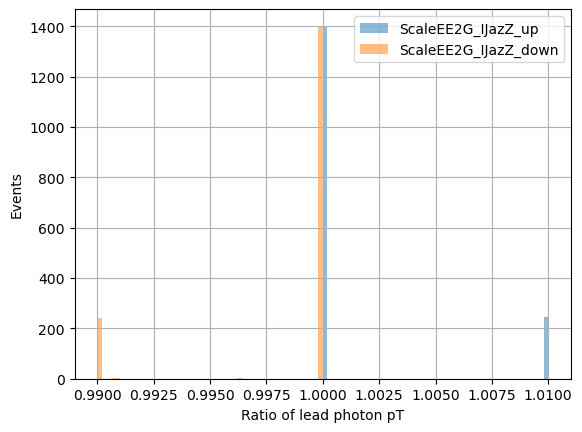

In [24]:
plt.hist(file_up_comm.pholead_pt/file_common.pholead_pt, bins=50, alpha=0.5, label='ScaleEE2G_IJazZ_up')
plt.hist(file_down_comm.pholead_pt/file_common.pholead_pt, bins=50, alpha=0.5, label='ScaleEE2G_IJazZ_down')
plt.xlabel('Ratio of lead photon pT')
plt.ylabel('Events')
plt.legend()
plt.grid()
plt.show()

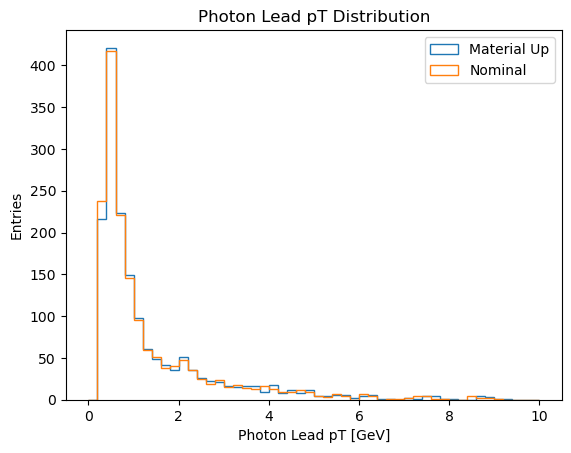

In [131]:
plt.hist(file_matup_comm.pholead_energyErr, bins=50, range=(0, 10), histtype='step', label='Material Up')
plt.hist(file_common.pholead_energyErr, bins=50, range=(0, 10), histtype='step', label='Nominal')
plt.xlabel('Photon Lead pT [GeV]')
plt.ylabel('Entries')
plt.title('Photon Lead pT Distribution')
plt.legend()
plt.show()

In [8]:
ROOT.gStyle.SetOptStat(0)

# Convert to numpy (important)
pt_nom = np.asarray(file_common.pholead_pt)
pt_up  = np.asarray(file_matup_comm.pholead_pt)

# Histogram settings
nbins = 100
xmin, xmax = 0, 200

h_nom = ROOT.TH1F("h_nom", "Photon Lead p_{T};p_{T} [GeV];Entries", nbins, xmin, xmax)
h_up  = ROOT.TH1F("h_up",  "Photon Lead p_{T};p_{T} [GeV];Entries", nbins, xmin, xmax)
h_nom.SetMinimum(0.1)
h_up.SetMinimum(0.1)

# Fill histograms
for x in pt_nom:
    h_nom.Fill(x)

for x in pt_up:
    h_up.Fill(x)

# Style
h_nom.SetLineColor(ROOT.kBlack)
h_nom.SetLineWidth(2)

h_up.SetLineColor(ROOT.kRed)
h_up.SetLineWidth(2)

# Canvas
c = ROOT.TCanvas("c", "Photon Lead pT", 800, 800)

# Pads
pad1 = ROOT.TPad("pad1", "pad1", 0, 0.30, 1, 1.00)
pad2 = ROOT.TPad("pad2", "pad2", 0, 0.00, 1, 0.30)

pad1.SetBottomMargin(0.02)
pad2.SetTopMargin(0.05)
pad2.SetBottomMargin(0.30)

pad1.Draw()
pad2.Draw()

# ---- Upper pad (main plot)
pad1.cd()
# pad1.SetLogy()

h_nom.Draw("HIST")
h_up.Draw("HIST SAME")

h_nom.GetYaxis().SetTitleOffset(1.2)
h_nom.GetXaxis().SetLabelSize(0)

# Legend
leg = ROOT.TLegend(0.60, 0.75, 0.88, 0.88)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.AddEntry(h_nom, "Nominal", "l")
leg.AddEntry(h_up,  "Material Up", "l")
leg.Draw()

# ---- Lower pad (ratio)
pad2.cd()


h_ratio = h_up.Clone("h_ratio")
h_ratio.Divide(h_nom)

h_ratio.SetTitle("")
h_ratio.GetYaxis().SetTitle("Up / Nominal")
h_ratio.GetYaxis().SetNdivisions(505)
h_ratio.GetYaxis().SetTitleSize(0.10)
h_ratio.GetYaxis().SetTitleOffset(0.45)
h_ratio.GetYaxis().SetLabelSize(0.08)

h_ratio.GetXaxis().SetTitle("p_{T} [GeV]")
h_ratio.GetXaxis().SetTitleSize(0.12)
h_ratio.GetXaxis().SetLabelSize(0.10)

h_ratio.SetLineColor(ROOT.kRed)
h_ratio.SetMarkerStyle(20)

h_ratio.SetMinimum(0.9)
h_ratio.SetMaximum(1.1)

h_ratio.Draw("P")

# Reference line at 1
line = ROOT.TLine(xmin, 1.0, xmax, 1.0)
line.SetLineStyle(2)
line.Draw()

c.Update()
c.Draw()


c.SaveAs("photon_lead_pt_material_up_vs_nominal.png")


Info in <TCanvas::Print>: png file photon_lead_pt_material_up_vs_nominal.png has been created


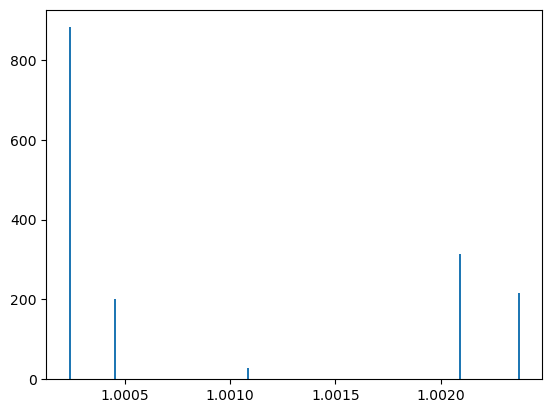

In [14]:
plt.hist(pt_up/pt_nom, bins = 200);

In [61]:
file.event_idx

<Array [13, 174, 183, 205, ..., 279765, 279814, 279846] type='3966 * int64'>

In [62]:
file_matup.event_idx

<Array [13, 174, 183, 205, ..., 279765, 279814, 279846] type='3959 * int64'>

In [1]:
import correctionlib
from correctionlib import CorrectionSet

In [2]:
json_file = "/eos/user/b/bbapi/JSON_checker/jet_jerc.json"

In [3]:
cset = CorrectionSet.from_file(json_file)

In [5]:
print(list(cset.keys()))

['Summer23BPixPrompt23_RunD_JRV1_MC_PtResolution_AK4PFPuppi', 'Summer23BPixPrompt23_RunD_JRV1_MC_ScaleFactor_AK4PFPuppi', 'Summer24Prompt24_V2_DATA_L1FastJet_AK4PFPuppi', 'Summer24Prompt24_V2_DATA_L2L3Residual_AK4PFPuppi', 'Summer24Prompt24_V2_DATA_L2Relative_AK4PFPuppi', 'Summer24Prompt24_V2_DATA_L3Absolute_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteFlavMap_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteMPFBias_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteSample_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteScale_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteStat_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupFlavor_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupIntercalibration_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupMPFInSitu_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupUncorrelated_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupbJES_AK4PFPuppi', 'Summer24Prompt24_V2_MC_FlavorPhotonJet_AK4PFPuppi', 'Summer24Prompt24_V2_MC_FlavorPureBottom_AK4PFPu

In [6]:
corr = cset["Summer24Prompt24_V2_MC_L1FastJet_AK4PFPuppi"]
print(corr.inputs)

[<correctionlib._core.Variable object at 0x7fdf300fab70>, <correctionlib._core.Variable object at 0x7fdf300fa130>, <correctionlib._core.Variable object at 0x7fdf300f91b0>, <correctionlib._core.Variable object at 0x7fdf300fa330>]


In [ ]:
for v in corr.inputs:
    print(f"name={v.name}, type={v.type}, desc={v.description}")

name=JetA, type=real, desc=area of the jet
name=JetEta, type=real, desc=pseudorapidity of the jet
name=JetPt, type=real, desc=pT of the jet before specific correction (for JER and uncertainties: after all corrections applied)
name=Rho, type=real, desc=energy density rho (as measure of PU)


In [20]:
jet_area = 0.4
jet_eta  = 0.4
jet_pt   = 23.0   # fully corrected pt if JES/JER
rho      = 10.0

unc = corr.evaluate(jet_area, jet_eta, jet_pt, rho)
print(unc)

1.0


In [12]:
print(corr.description)

L1FastJet for AK4PFPuppi jets, created from Summer24Prompt24_V2_MC using https://gitlab.cern.ch/cms-jetmet/jerc2json


In [13]:
print(corr.output)

In [15]:
v = corr.output
print(f"name={v.name}, type={v.type}, desc={v.description}")


name=correction, type=real, desc=


In [21]:
print(corr.name)

Summer24Prompt24_V2_MC_L1FastJet_AK4PFPuppi


In [24]:
dir(corr)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_base',
 '_context',
 '_name',
 'description',
 'evaluate',
 'inputs',
 'name',
 'output',
 'version']

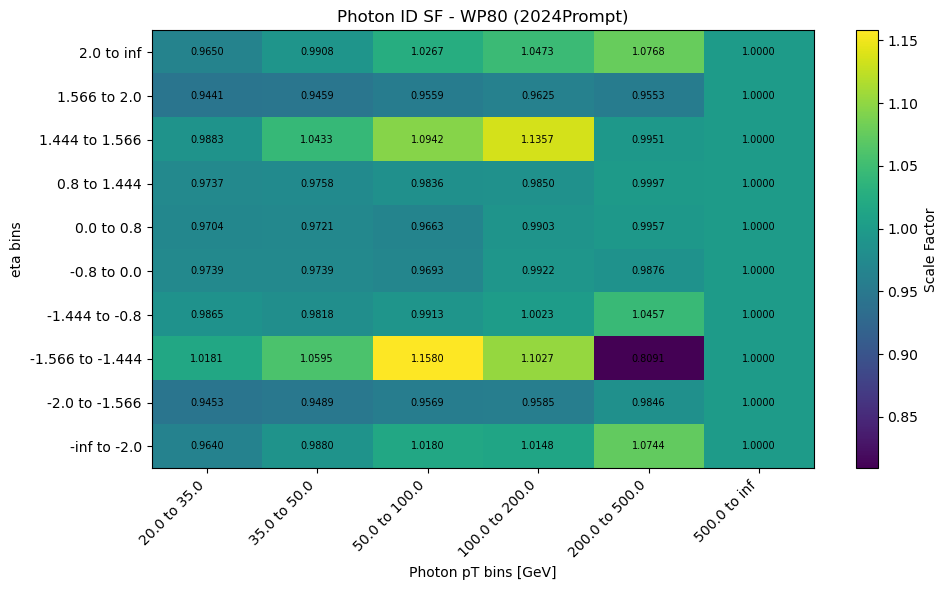

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load JSON file
with open("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Miscellaneous/photon.json", "r") as f:
    data = json.load(f)

# Navigate to WP80 block
corrections = data["corrections"]

wp80 = None

for corr in corrections:
    if corr["name"] == "Photon-ID-SF":

        year_content = corr["data"]["content"]

        for year_block in year_content:
            if year_block["key"] == "2024Prompt":

                valtype_content = year_block["value"]["content"]

                for val_block in valtype_content:
                    if val_block["key"] == "sf":

                        wp_content = val_block["value"]["content"]

                        for wp_block in wp_content:
                            if wp_block["key"] == "wp80":
                                wp80 = wp_block["value"]

# Extract edges and content
eta_edges = wp80["edges"][0]
pt_edges  = wp80["edges"][1]
values    = wp80["content"]

# Remove inf strings for plotting labels
eta_labels = []
for i in range(len(eta_edges)-1):
    eta_labels.append(f"{eta_edges[i]} to {eta_edges[i+1]}")

pt_labels = []
for i in range(len(pt_edges)-1):
    pt_labels.append(f"{pt_edges[i]} to {pt_edges[i+1]}")

# Convert flat content to 2D array
n_eta = len(eta_edges) - 1
n_pt  = len(pt_edges) - 1

arr = np.array(values).reshape(n_eta, n_pt)

# Mask overflow placeholder values
# arr_masked = np.where(arr > 0.1, np.nan, arr)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(arr, aspect='auto', origin='lower')

# Axis labels
ax.set_xticks(np.arange(n_pt))
ax.set_xticklabels(pt_labels, rotation=45, ha='right')

ax.set_yticks(np.arange(n_eta))
ax.set_yticklabels(eta_labels)

ax.set_xlabel("Photon pT bins [GeV]")
ax.set_ylabel("eta bins")
ax.set_title("Photon ID SF - WP80 (2024Prompt)")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Scale Factor")

# Write values on cells
for i in range(n_eta):
    for j in range(n_pt):
        val = arr[i, j]
        if not np.isnan(val):
            ax.text(
                j, i,
                f"{val:.4f}",
                ha='center',
                va='center',
                fontsize=7
            )

plt.tight_layout()
plt.savefig(Plot_dir+"wp80_plot.png", dpi=300)
plt.show()

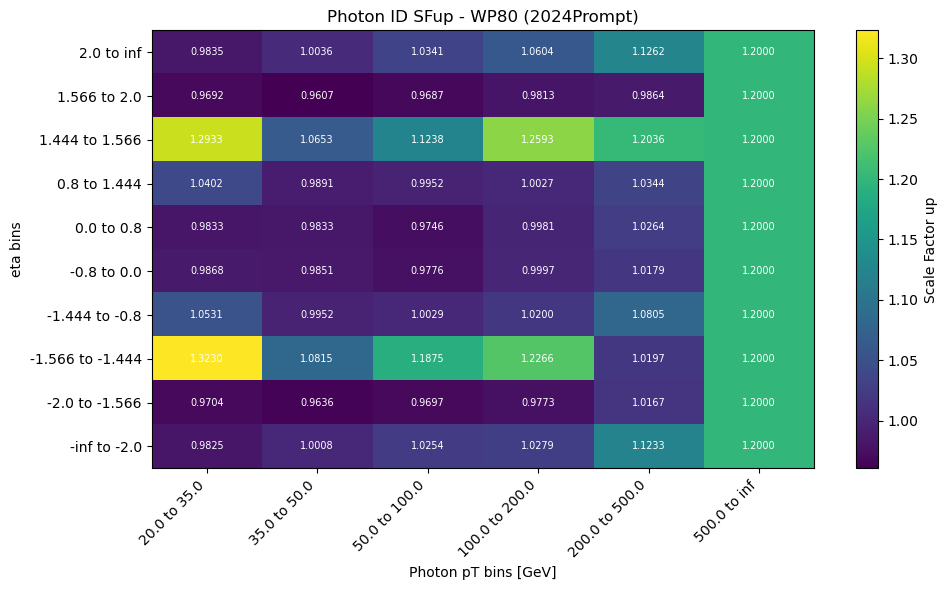

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load JSON file
with open("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Miscellaneous/photon.json", "r") as f:
    data = json.load(f)

# Navigate to WP80 block
corrections = data["corrections"]

wp80 = None

for corr in corrections:
    if corr["name"] == "Photon-ID-SF":

        year_content = corr["data"]["content"]

        for year_block in year_content:
            if year_block["key"] == "2024Prompt":

                valtype_content = year_block["value"]["content"]

                for val_block in valtype_content:
                    if val_block["key"] == "sfup":

                        wp_content = val_block["value"]["content"]

                        for wp_block in wp_content:
                            if wp_block["key"] == "wp80":
                                wp80 = wp_block["value"]

# Extract edges and content
eta_edges = wp80["edges"][0]
pt_edges  = wp80["edges"][1]
values    = wp80["content"]

# Remove inf strings for plotting labels
eta_labels = []
for i in range(len(eta_edges)-1):
    eta_labels.append(f"{eta_edges[i]} to {eta_edges[i+1]}")

pt_labels = []
for i in range(len(pt_edges)-1):
    pt_labels.append(f"{pt_edges[i]} to {pt_edges[i+1]}")

# Convert flat content to 2D array
n_eta = len(eta_edges) - 1
n_pt  = len(pt_edges) - 1

arr = np.array(values).reshape(n_eta, n_pt)

# Mask overflow placeholder values
# arr_masked = np.where(arr > 0.1, np.nan, arr)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(arr, aspect='auto', origin='lower')

# Axis labels
ax.set_xticks(np.arange(n_pt))
ax.set_xticklabels(pt_labels, rotation=45, ha='right')

ax.set_yticks(np.arange(n_eta))
ax.set_yticklabels(eta_labels)

ax.set_xlabel("Photon pT bins [GeV]")
ax.set_ylabel("eta bins")
ax.set_title("Photon ID SFup - WP80 (2024Prompt)")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Scale Factor up")

# Write values on cells
for i in range(n_eta):
    for j in range(n_pt):
        val = arr[i, j]
        if not np.isnan(val):
            ax.text(
                j, i,
                f"{val:.4f}",
                ha='center',
                va='center',
                fontsize=7,
                color='white'
            )

plt.tight_layout()
plt.savefig(Plot_dir+"wp80up_plot.png", dpi=300)
plt.show()

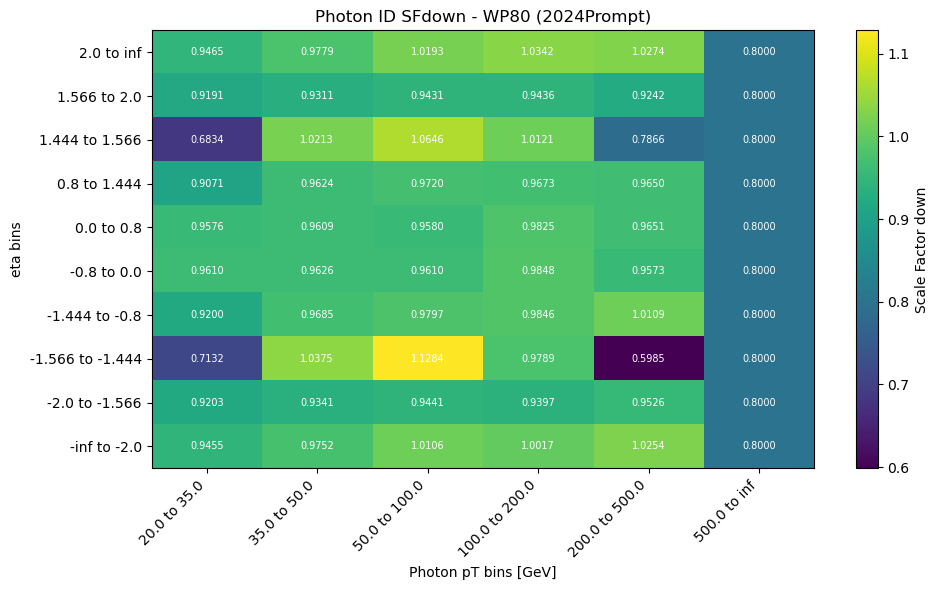

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt

# Load JSON file
with open("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Miscellaneous/photon.json", "r") as f:
    data = json.load(f)

# Navigate to WP80 block
corrections = data["corrections"]

wp80 = None

for corr in corrections:
    if corr["name"] == "Photon-ID-SF":

        year_content = corr["data"]["content"]

        for year_block in year_content:
            if year_block["key"] == "2024Prompt":

                valtype_content = year_block["value"]["content"]

                for val_block in valtype_content:
                    if val_block["key"] == "sfdown":

                        wp_content = val_block["value"]["content"]

                        for wp_block in wp_content:
                            if wp_block["key"] == "wp80":
                                wp80 = wp_block["value"]

# Extract edges and content
eta_edges = wp80["edges"][0]
pt_edges  = wp80["edges"][1]
values    = wp80["content"]

# Remove inf strings for plotting labels
eta_labels = []
for i in range(len(eta_edges)-1):
    eta_labels.append(f"{eta_edges[i]} to {eta_edges[i+1]}")

pt_labels = []
for i in range(len(pt_edges)-1):
    pt_labels.append(f"{pt_edges[i]} to {pt_edges[i+1]}")

# Convert flat content to 2D array
n_eta = len(eta_edges) - 1
n_pt  = len(pt_edges) - 1

arr = np.array(values).reshape(n_eta, n_pt)

# Mask overflow placeholder values
# arr_masked = np.where(arr > 0.1, np.nan, arr)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(arr, aspect='auto', origin='lower')

# Axis labels
ax.set_xticks(np.arange(n_pt))
ax.set_xticklabels(pt_labels, rotation=45, ha='right')

ax.set_yticks(np.arange(n_eta))
ax.set_yticklabels(eta_labels)

ax.set_xlabel("Photon pT bins [GeV]")
ax.set_ylabel("eta bins")
ax.set_title("Photon ID SFdown - WP80 (2024Prompt)")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Scale Factor down")

# Write values on cells
for i in range(n_eta):
    for j in range(n_pt):
        val = arr[i, j]
        if not np.isnan(val):
            ax.text(
                j, i,
                f"{val:.4f}",
                ha='center',
                va='center',
                fontsize=7,
                color='white'
            )

plt.tight_layout()
plt.savefig(Plot_dir+"wp80down_plot.png", dpi=300)
plt.show()

In [ ]:
wp80

{'nodetype': 'multibinning',
 'inputs': ['eta', 'pt'],
 'edges': [['-inf',
   -2.0,
   -1.566,
   -1.444,
   -0.8,
   0.0,
   0.8,
   1.444,
   1.566,
   2.0,
   'inf'],
  [20.0, 35.0, 50.0, 100.0, 200.0, 500.0, 'inf']],
 'content': [0.964016854763031,
  0.9880019426345825,
  1.018041968345642,
  1.0147825479507446,
  1.0743839740753174,
  1.0,
  0.9453373551368713,
  0.9488735795021057,
  0.9568822979927063,
  0.9584811925888062,
  0.9846135377883911,
  1.0,
  1.0180834531784058,
  1.0594924688339233,
  1.1579632759094238,
  1.102708101272583,
  0.809069812297821,
  1.0,
  0.9865200519561768,
  0.9818423390388489,
  0.991260290145874,
  1.002293348312378,
  1.0456942319869995,
  1.0,
  0.9738876223564148,
  0.9738537073135376,
  0.96927809715271,
  0.9922305941581726,
  0.9875999093055725,
  1.0,
  0.9704474210739136,
  0.9721023440361023,
  0.9663314819335938,
  0.9902967214584351,
  0.9957494139671326,
  1.0,
  0.9736510515213013,
  0.9757676720619202,
  0.9836201667785645,
  0.9850

In [9]:
values

[0.964016854763031,
 0.9880019426345825,
 1.018041968345642,
 1.0147825479507446,
 1.0743839740753174,
 1.0,
 0.9453373551368713,
 0.9488735795021057,
 0.9568822979927063,
 0.9584811925888062,
 0.9846135377883911,
 1.0,
 1.0180834531784058,
 1.0594924688339233,
 1.1579632759094238,
 1.102708101272583,
 0.809069812297821,
 1.0,
 0.9865200519561768,
 0.9818423390388489,
 0.991260290145874,
 1.002293348312378,
 1.0456942319869995,
 1.0,
 0.9738876223564148,
 0.9738537073135376,
 0.96927809715271,
 0.9922305941581726,
 0.9875999093055725,
 1.0,
 0.9704474210739136,
 0.9721023440361023,
 0.9663314819335938,
 0.9902967214584351,
 0.9957494139671326,
 1.0,
 0.9736510515213013,
 0.9757676720619202,
 0.9836201667785645,
 0.9850011467933655,
 0.9997212290763855,
 1.0,
 0.9883353114128113,
 1.043315052986145,
 1.0942052602767944,
 1.1356940269470215,
 0.9950737357139587,
 1.0,
 0.9441328048706055,
 0.94590163230896,
 0.9559214115142822,
 0.9624536633491516,
 0.9553049206733704,
 1.0,
 0.965021789

In [11]:
arr_masked

array([[nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan]])

In [2]:
import glob
file = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/NTuples_WH_2024_single_correction_check_HDNA_Smearing2G_IJazZ/WH-2024M30/nominal/diphoton/'
files = glob.glob(file+"*.parquet")
events = ak.from_parquet(files)
events.fields


['pholead_cutBased',
 'pholead_electronVeto',
 'pholead_hasConversionTracks',
 'pholead_isScEtaEB',
 'pholead_isScEtaEE',
 'pholead_mvaID_WP80',
 'pholead_mvaID_WP90',
 'pholead_pixelSeed',
 'pholead_seedGain',
 'pholead_electronIdx',
 'pholead_jetIdx',
 'pholead_seediEtaOriX',
 'pholead_seediPhiOriY',
 'pholead_vidNestedWPBitmap',
 'pholead_ecalPFClusterIso',
 'pholead_energyErr',
 'pholead_energyRaw',
 'pholead_esEffSigmaRR',
 'pholead_esEnergyOverRawE',
 'pholead_eta',
 'pholead_etaWidth',
 'pholead_haloTaggerMVAVal',
 'pholead_hcalPFClusterIso',
 'pholead_hoe',
 'pholead_hoe_PUcorr',
 'pholead_hoe_Tower',
 'pholead_mvaID',
 'pholead_pfChargedIso',
 'pholead_pfChargedIsoPFPV',
 'pholead_pfChargedIsoWorstVtx',
 'pholead_pfPhoIso03',
 'pholead_pfRelIso03_all_quadratic',
 'pholead_pfRelIso03_chg_quadratic',
 'pholead_phi',
 'pholead_phiWidth',
 'pholead_r9',
 'pholead_s4',
 'pholead_sieie',
 'pholead_sieip',
 'pholead_sipip',
 'pholead_superclusterEta',
 'pholead_trkSumPtHollowConeDR03

In [4]:
filtered_events = events[(events.pholead_pt > 19.92882) & (events.pholead_pt < 27.50581) & (events.pholead_r9>0.975) & (events.pholead_eta>2.0) & (events.pholead_eta<2.5) & (events.phosublead_pt > 19.92882) & (events.phosublead_pt < 27.50581) & (events.phosublead_r9>0.975) & (events.phosublead_eta>2.0) & (events.phosublead_eta<2.5)]

In [5]:
len(filtered_events)

12

In [6]:
filtered_events.mass

<Array [27.6, 31.5, 30.3, 31.7, ..., 30.5, 30, 39.8, 31] type='12 * ?float64'>

In [7]:
len(events)

43134

In [8]:
file_down = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/NTuples_WH_2024_single_correction_check_HDNA_Smearing2G_IJazZ/WH-2024M30/Smearing2G_IJazZ_down/diphoton/'
files_down = glob.glob(file_down+"*.parquet")
events_down = ak.from_parquet(files_down)
events_down.fields

['pholead_cutBased',
 'pholead_electronVeto',
 'pholead_hasConversionTracks',
 'pholead_isScEtaEB',
 'pholead_isScEtaEE',
 'pholead_mvaID_WP80',
 'pholead_mvaID_WP90',
 'pholead_pixelSeed',
 'pholead_seedGain',
 'pholead_electronIdx',
 'pholead_jetIdx',
 'pholead_seediEtaOriX',
 'pholead_seediPhiOriY',
 'pholead_vidNestedWPBitmap',
 'pholead_ecalPFClusterIso',
 'pholead_energyErr',
 'pholead_energyRaw',
 'pholead_esEffSigmaRR',
 'pholead_esEnergyOverRawE',
 'pholead_eta',
 'pholead_etaWidth',
 'pholead_haloTaggerMVAVal',
 'pholead_hcalPFClusterIso',
 'pholead_hoe',
 'pholead_hoe_PUcorr',
 'pholead_hoe_Tower',
 'pholead_mvaID',
 'pholead_pfChargedIso',
 'pholead_pfChargedIsoPFPV',
 'pholead_pfChargedIsoWorstVtx',
 'pholead_pfPhoIso03',
 'pholead_pfRelIso03_all_quadratic',
 'pholead_pfRelIso03_chg_quadratic',
 'pholead_phi',
 'pholead_phiWidth',
 'pholead_r9',
 'pholead_s4',
 'pholead_sieie',
 'pholead_sieip',
 'pholead_sipip',
 'pholead_superclusterEta',
 'pholead_trkSumPtHollowConeDR03

In [9]:
filtered_events_down = events_down[(events_down.pholead_pt > 19.92882) & (events_down.pholead_pt < 27.50581) & (events_down.pholead_r9>0.975) & (events_down.pholead_eta>2.0) & (events_down.pholead_eta<2.5) & (events_down.phosublead_pt > 19.92882) & (events_down.phosublead_pt < 27.50581) & (events_down.phosublead_r9>0.975) & (events_down.phosublead_eta>2.0) & (events_down.phosublead_eta<2.5)]

In [11]:
len(filtered_events_down)

11

In [12]:
filtered_events.event

<Array [586192, 133208, 866826, ..., 692978, 151239] type='12 * ?uint64'>

In [14]:
filtered_events_down.event

<Array [586192, 133208, 866826, ..., 692978, 151239] type='11 * ?uint64'>

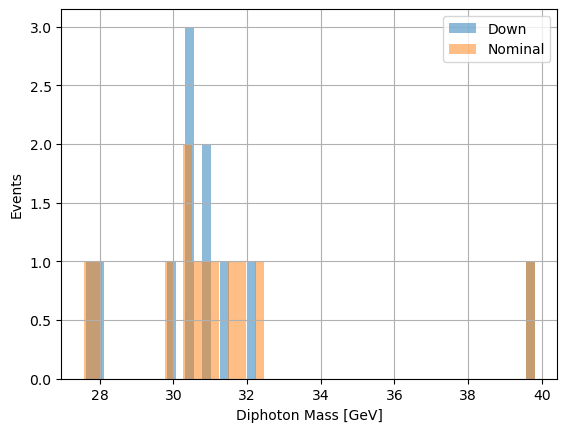

In [15]:
plt.hist(filtered_events_down.mass, bins=50, alpha=0.5, label='Down')
plt.hist(filtered_events.mass, bins=50, alpha=0.5, label='Nominal')
plt.xlabel('Diphoton Mass [GeV]')
plt.ylabel('Events')
plt.legend()
plt.grid()
plt.show()